## 1. Import Libraries

In [1]:

import pandas as pd

import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import confusion_matrix, accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
# Import files module for uploading dataset in Colab
from google.colab import files
# Prompt user to upload classification_data.csv
uploaded = files.upload()
# Load the dataset from the uploaded CSV file
df = pd.read_csv('classification_data.csv')
# Display the first 5 rows to verify loading
print(df.head())

Saving classification_data.csv to classification_data.csv
        Age     Grade  Tumor_Size  Regional_Node_Examined  \
0  1.550325  1.330387   -1.253980                1.184029   
1 -0.443977 -0.236080    0.215056               -0.046389   
2  0.442379 -0.236080    1.541927               -0.046389   
3  0.442379  1.330387   -0.590544               -1.522891   
4 -0.776361  1.330387    0.499386               -1.399849   

   Reginol_Node_Positive  Mortality_Status  Sex_Female  T_Stage_T2  \
0              -0.618426                 1        True       False   
1               0.164352                 1        True        True   
2               0.555742                 1        True       False   
3              -0.618426                 1        True       False   
4              -0.618426                 1        True        True   

   T_Stage_T3  T_Stage_T4  ...  6th_Stage_IIB  6th_Stage_IIIA  6th_Stage_IIIB  \
0       False       False  ...          False           False           F

## 3. Data Understanding: Variable Types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4021 entries, 0 to 4020
Data columns (total 22 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   4021 non-null   float64
 1   Grade                                 4021 non-null   float64
 2   Tumor_Size                            4021 non-null   float64
 3   Regional_Node_Examined                4021 non-null   float64
 4   Reginol_Node_Positive                 4021 non-null   float64
 5   Mortality_Status                      4021 non-null   int64  
 6   Sex_Female                            4021 non-null   bool   
 7   T_Stage_T2                            4021 non-null   bool   
 8   T_Stage_T3                            4021 non-null   bool   
 9   T_Stage_T4                            4021 non-null   bool   
 10  N_Stage_N2                            4021 non-null   bool   
 11  N_Stage_N3       

In [4]:
# Set display options to show all columns and up 500 rows
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 150)

## 4. Define Input Features and Target

In [5]:
# Define input features (all columns except Mortality_Status)
X = df.drop(columns=['Mortality_Status'])
# Define target variable (Mortality_Status)
y = df['Mortality_Status']
# Display shapes of X and y to verify
print('Input Features Shape:', X.shape)
print('Target Shape:', y.shape)

Input Features Shape: (4021, 21)
Target Shape: (4021,)


## 5. Split Data into Training and Testing Sets

In [6]:
# Set random seed for reproducibility
random_seed = 42
# Split data into 80% training and 20% testing

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Display shapes of training and testing sets
print('Training Features Shape:', X_train.shape)
print('Training Target Shape:', y_train.shape)
print('Testing Features Shape:', X_test.shape)
print('Testing Target Shape:', y_test.shape)

Training Features Shape: (3216, 21)
Training Target Shape: (3216,)
Testing Features Shape: (805, 21)
Testing Target Shape: (805,)


In [7]:
# Print data ratio for the each traning and testing data set
print("Train label ratio:", y_train.value_counts(normalize=True))
print("Test label ratio:", y_test.value_counts(normalize=True))


Train label ratio: Mortality_Status
1    0.847015
0    0.152985
Name: proportion, dtype: float64
Test label ratio: Mortality_Status
1    0.847205
0    0.152795
Name: proportion, dtype: float64


## 6. Train and Evaluate Logistic Regression

Classification Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.64      0.15      0.24       123
           1       0.86      0.99      0.92       682

    accuracy                           0.86       805
   macro avg       0.75      0.57      0.58       805
weighted avg       0.83      0.86      0.82       805

Logistic Regression Accuracy: 0.8571428571428571
Logistic Regression Confusion Matrix:
 [[ 18 105]
 [ 10 672]]


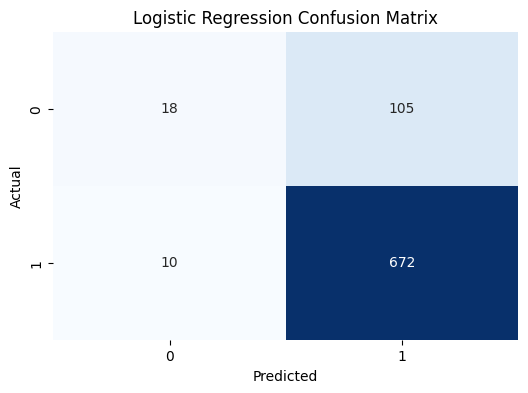

Logistic Regression AOC-ROC


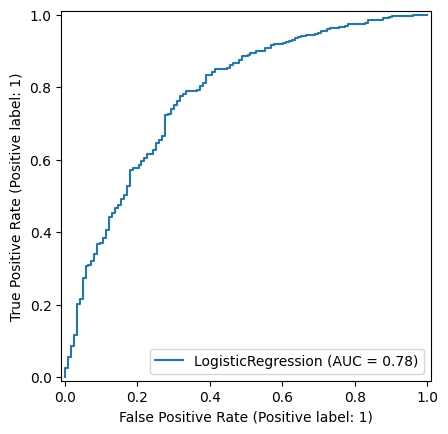

In [9]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay

# Initialize Logistic Regression model
lr_model = LogisticRegression(random_state=42)
# Train the model on the training data
lr_model.fit(X_train, y_train)
# Predict on the test data
lr_predictions = lr_model.predict(X_test)

# compare to predicted model
Comparison_df = pd.DataFrame({"Actual": y_test, "Predicted": lr_predictions})



# add classification report
print("Classification Report: Logistic Regression")
print(classification_report(y_test, lr_predictions))

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, lr_predictions)
# Display accuracy
print('Logistic Regression Accuracy:', lr_accuracy)

# Generate confusion matrix
lr_cm = confusion_matrix(y_test, lr_predictions)
print("Logistic Regression Confusion Matrix:\n", lr_cm)
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(lr_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# create AOC_ROC curve
print("Logistic Regression AOC-ROC")
lr_roc = RocCurveDisplay.from_estimator(lr_model, X_test, y_test)


Best Parameters from GridSearchCV: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.9204067526067707
Classification Report (Tuned Logistic Regression):
              precision    recall  f1-score   support

           0       0.67      0.15      0.24       123
           1       0.87      0.99      0.92       682

    accuracy                           0.86       805
   macro avg       0.77      0.57      0.58       805
weighted avg       0.83      0.86      0.82       805

Logistic Regression Accuracy: 0.8583850931677018
Tuned Logistic Regression Confusion Matrix:
 [[ 18 105]
 [  9 673]]


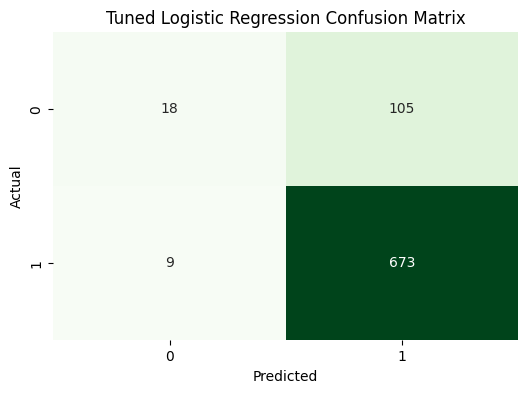

 Tuned Logistic Regression AOC-ROC


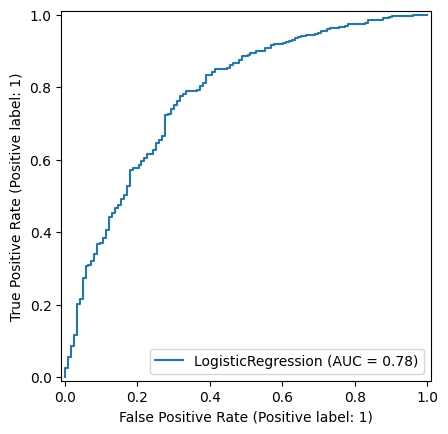

In [10]:
# GridSearchCV for Logistic Regression
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Set up GridSearchCV with 5-fold cross-validation
grid_search_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), param_grid_lr, cv=5, scoring='f1')

# Train using GridSearch
grid_search_lr.fit(X_train, y_train)

# Best hyperparameters and performance
print("Best Parameters from GridSearchCV:", grid_search_lr.best_params_)
print("Best Cross-Validation Score:", grid_search_lr.best_score_)

# Predict using best estimator
tuned_lr_predictions = grid_search_lr.predict(X_test)

# Classification Report for tuned model
print("Classification Report (Tuned Logistic Regression):")
print(classification_report(y_test, tuned_lr_predictions))

# Calculate accuracy
tuned_lr_accuracy = accuracy_score(y_test, tuned_lr_predictions)
# Display accuracy
print('Logistic Regression Accuracy:', tuned_lr_accuracy)
# Confusion Matrix for tuned model
tuned_lr_cm = confusion_matrix(y_test, tuned_lr_predictions)
print("Tuned Logistic Regression Confusion Matrix:\n", tuned_lr_cm)

#display Confution Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(tuned_lr_cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Tuned Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#roc curve
print(" Tuned Logistic Regression AOC-ROC")
tuned_lr_roc = RocCurveDisplay.from_estimator(lr_model, X_test, y_test)


## 7. Train and Evaluate Naive Bayes

Classification Report: Naive Bayes
              precision    recall  f1-score   support

           0       0.22      0.84      0.35       123
           1       0.94      0.48      0.63       682

    accuracy                           0.53       805
   macro avg       0.58      0.66      0.49       805
weighted avg       0.83      0.53      0.59       805

Naive Bayes Accuracy: 0.5316770186335403
Naive Bayes Confusion Matrix:
 [[103  20]
 [357 325]]


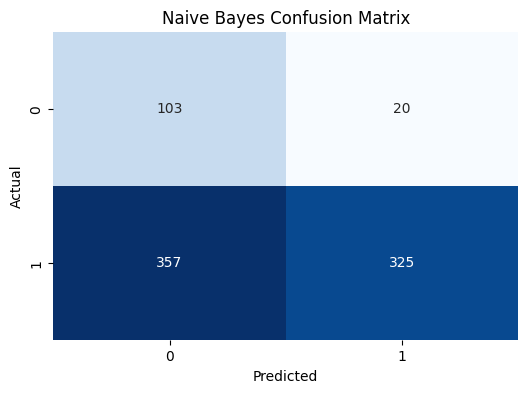

 Native Bayes AOC-ROC 


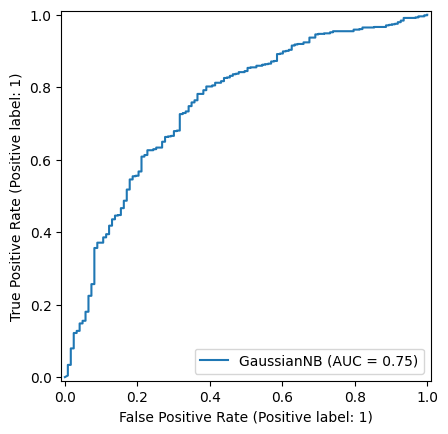

In [11]:
# Initialize Gaussian Naive Bayes model
nb_model = GaussianNB()
# Train the model on the training data
nb_model.fit(X_train, y_train)
# Predict on the test data
nb_predictions = nb_model.predict(X_test)

# add classification report
print("Classification Report: Naive Bayes")
print(classification_report(y_test, nb_predictions))

# Calculate accuracy
nb_accuracy = accuracy_score(y_test, nb_predictions)
# Display accuracy
print('Naive Bayes Accuracy:', nb_accuracy)

# Generate confusion matrix
nb_cm = confusion_matrix(y_test, nb_predictions)
print("Naive Bayes Confusion Matrix:\n", nb_cm)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(nb_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# AUC-ROC Curves
print(" Native Bayes AOC-ROC ")
nb_roc = RocCurveDisplay.from_estimator(nb_model, X_test, y_test)


## 8. Train and Evaluate K-Nearest Neighbors

Classification Report: K-Nearest Neighbours
              precision    recall  f1-score   support

           0       0.39      0.15      0.22       123
           1       0.86      0.96      0.91       682

    accuracy                           0.83       805
   macro avg       0.63      0.56      0.56       805
weighted avg       0.79      0.83      0.80       805

KNN Accuracy: 0.8335403726708075
KNN Confusion Matrix:
 [[ 19 104]
 [ 30 652]]


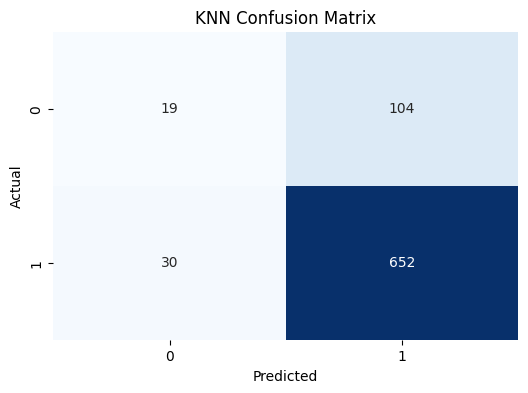

 KNN AUC-ROC 


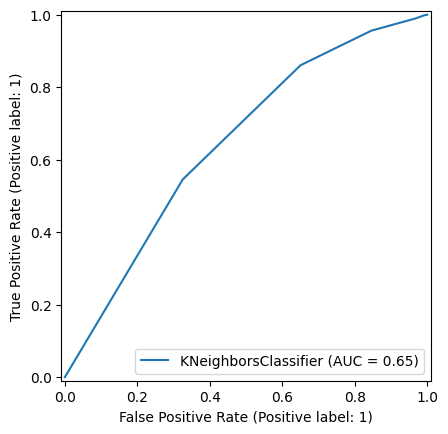

In [12]:
# Initialize K-Nearest Neighbors model with 5 neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
# Train the model on the training data
knn_model.fit(X_train, y_train)
# Predict on the test data
knn_predictions = knn_model.predict(X_test)

# add classification report
print("Classification Report: K-Nearest Neighbours")
print(classification_report(y_test, knn_predictions))

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, knn_predictions)
# Display accuracy
print('KNN Accuracy:', knn_accuracy)

# Generate confusion matrix
knn_cm = confusion_matrix(y_test, knn_predictions)
print("KNN Confusion Matrix:\n", knn_cm)
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# AUC-ROC Curves
print(" KNN AUC-ROC ")
knn_roc = RocCurveDisplay.from_estimator(knn_model, X_test, y_test)

